<a href="https://colab.research.google.com/github/ythapa586/-problempulse/blob/main/wine_quality_prediction_(KNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🍷 Wine Quality Prediction using K-Nearest Neighbors (KNN)

📌 Objective  
To classify whether a wine is Good or Bad based on its chemical properties using the K-Nearest Neighbors (KNN) algorithm.

⚠️ Approach  
Good Wine → quality ≥ 7 → 1  
Bad Wine → quality < 7 → 0  

## 📦 Import Libraries  
We import libraries for data handling, visualization, preprocessing, and machine learning.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 📂 Load Dataset  
Load the dataset and display first few rows.

In [ ]:
df = pd.read_csv('winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 🔍 Data Understanding  
Check structure, statistics, and missing values.

In [ ]:
df.shape
df.info()
df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## 🎯 Target Conversion  
Convert quality into binary classification:

1 → Good Wine (≥7)  
0 → Bad Wine (<7)

In [ ]:
X = df.drop('quality', axis=1)
y = df['quality']

y = y.apply(lambda x: 1 if x >= 7 else 0)

## 📊 Data Visualization  
Visualize feature correlation.

/tmp/ipykernel_1168/1504123106.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['quality'], palette='viridis')


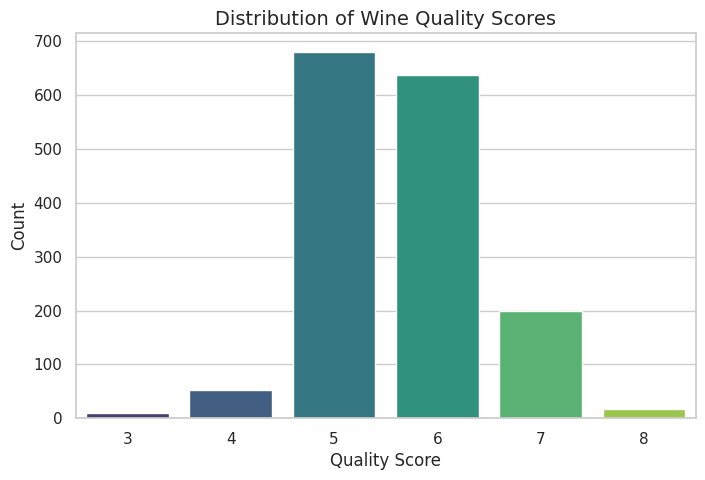


-----------------------------------------------



/tmp/ipykernel_1168/1504123106.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='coolwarm')


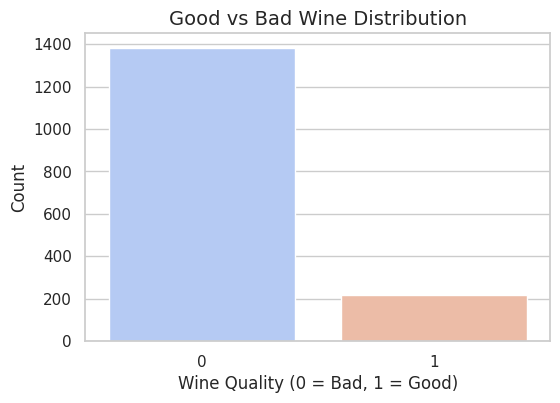


-----------------------------------------------



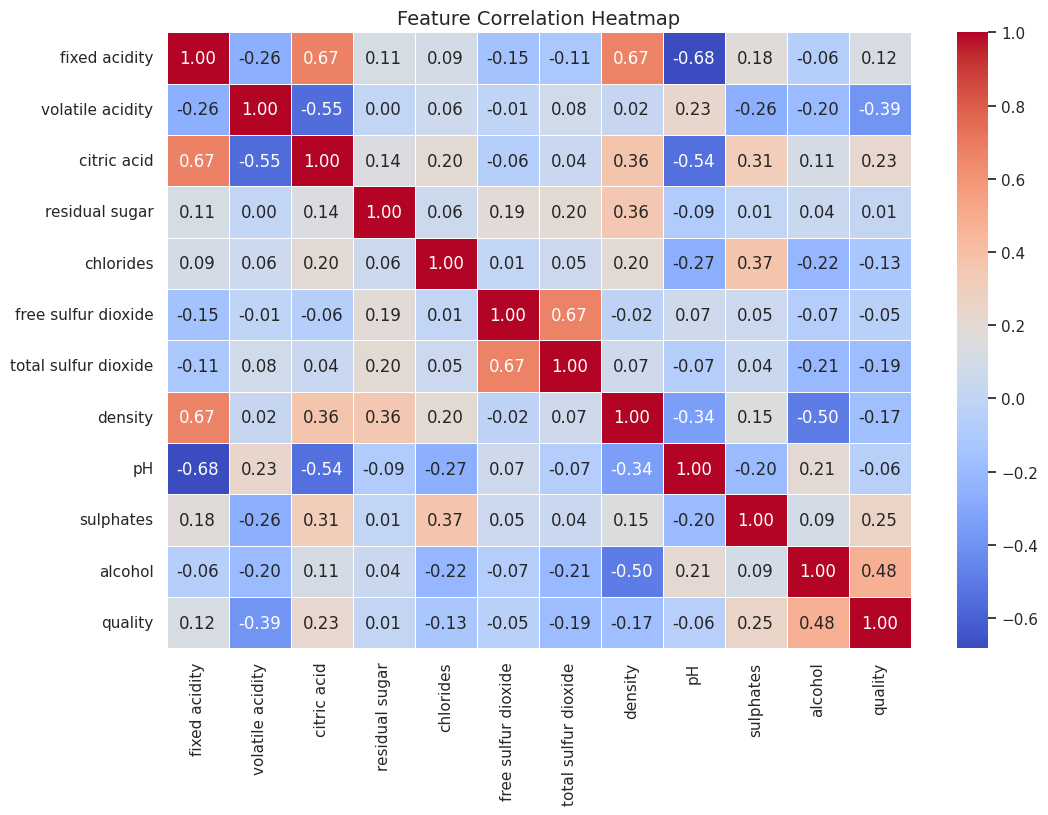


-----------------------------------------------



KeyboardInterrupt: 

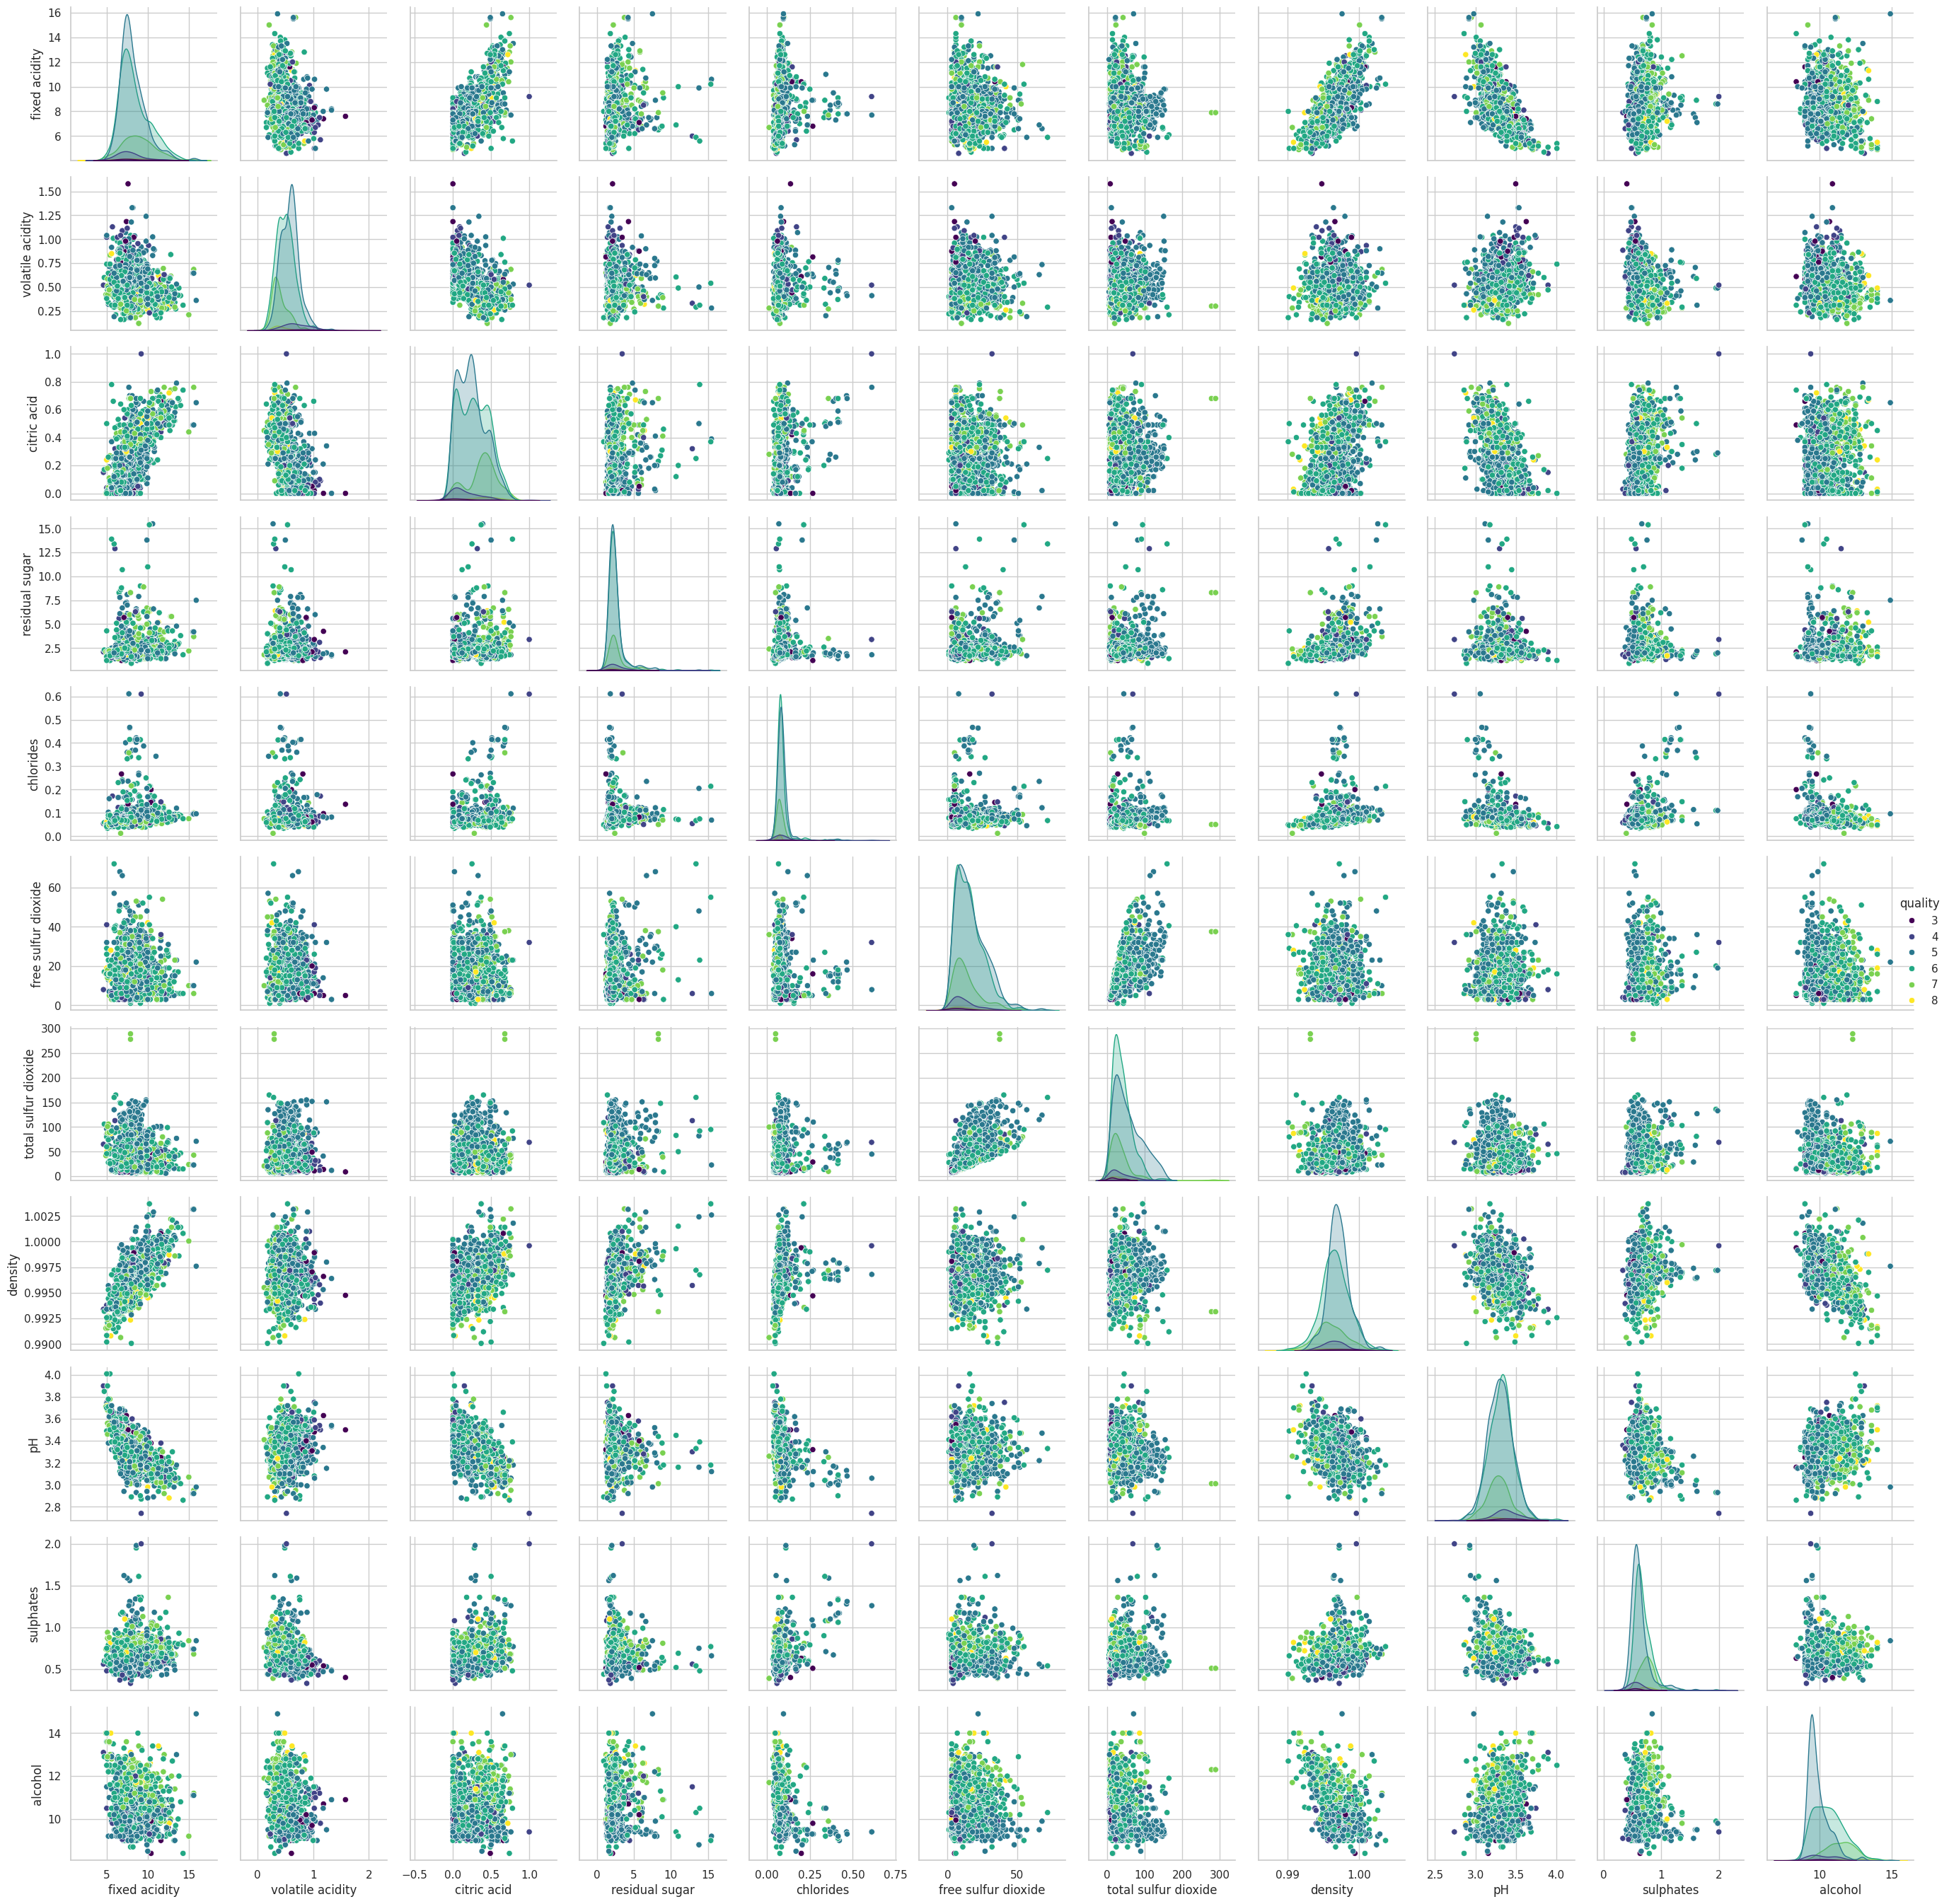

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

# -----------------------------------------------
# 1. Wine Quality Distribution
# -----------------------------------------------
plt.figure(figsize=(8,5))
sns.countplot(x=df['quality'], palette='viridis')
plt.title("Distribution of Wine Quality Scores", fontsize=14)
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

print("\n-----------------------------------------------\n")

# -----------------------------------------------
# 2. Binary Classification Distribution
# -----------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette='coolwarm')
plt.title("Good vs Bad Wine Distribution", fontsize=14)
plt.xlabel("Wine Quality (0 = Bad, 1 = Good)")
plt.ylabel("Count")
plt.show()

print("\n-----------------------------------------------\n")

# -----------------------------------------------
# 3. Correlation Heatmap
# -----------------------------------------------
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

print("\n-----------------------------------------------\n")

# -----------------------------------------------
# 4. Pairplot (Feature Relationships)
# -----------------------------------------------
sns.pairplot(df, hue='quality', palette='viridis')
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

print("\n-----------------------------------------------\n")

# -----------------------------------------------
# 5. Feature Distributions
# -----------------------------------------------
df.hist(figsize=(12,10), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

print("\n-----------------------------------------------\n")

# -----------------------------------------------
# 6. K vs Accuracy Graph
# -----------------------------------------------
k_values = list(range(1, 21))
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o', linestyle='--')
plt.title("K Value vs Accuracy (KNN Performance)", fontsize=14)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

print("\n-----------------------------------------------\n")

# -----------------------------------------------
# 7. Final Model (Best K)
# -----------------------------------------------
best_k = k_values[np.argmax(accuracies)]
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# -----------------------------------------------
# 8. Confusion Matrix
# -----------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n-----------------------------------------------\n")

# -----------------------------------------------
# 9. Classification Report
# -----------------------------------------------
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\n-----------------------------------------------\n")

# -----------------------------------------------
# 10. ROC Curve
# -----------------------------------------------
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("\n-----------------------------------------------\n")

# -----------------------------------------------
# 11. PCA Visualization (2D Decision Boundary)
# -----------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('quality', axis=1))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model_pca = KNeighborsClassifier(n_neighbors=best_k)
model_pca.fit(X_train_pca, y_train_pca)

# Meshgrid
x_min, x_max = X_pca[:,0].min() - 1, X_pca[:,0].max() + 1
y_min, y_max = X_pca[:,1].min() - 1, X_pca[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', edgecolor='k')

plt.title("KNN Decision Boundary (PCA Reduced)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print("\n-----------------------------------------------\n")

## ✂️ Train-Test Split  
Split dataset into training and testing data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 📏 Feature Scaling  
Scale features because KNN is distance-based.

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 🤖 Model Training  
Train KNN model.

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

## 🔮 Prediction  
Predict results on test data.

In [ ]:
y_pred = knn.predict(X_test)

## 📊 Model Evaluation  
Evaluate model performance.

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.88125

Confusion Matrix:
 [[262  11]
 [ 27  20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93       273
           1       0.65      0.43      0.51        47

    accuracy                           0.88       320
   macro avg       0.78      0.69      0.72       320
weighted avg       0.87      0.88      0.87       320



## 📉 Hyperparameter Tuning  
Find the best K value.

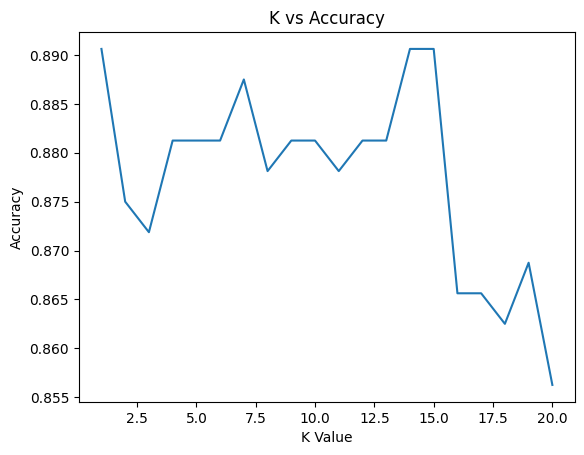

In [ ]:
accuracy = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy.append(accuracy_score(y_test, pred))

plt.plot(range(1,21), accuracy)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

## 🏁 Final Model  
Train model with optimal K.

In [ ]:
final_model = KNeighborsClassifier(n_neighbors=7)
final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, final_pred))

Final Accuracy: 0.8875


## ✅ Conclusion  
KNN successfully classified wine quality.  
Feature scaling improved performance.  
Choosing optimal K is important.

🔮 Improvements:
- Use cross-validation  
- Try Logistic Regression / Random Forest  
- Handle class imbalance  